# **City Landscape in Sight: A Crowdsourced Framework for Unlocking Urban-Scale Window View Perceptions from Real Estate Imagery**

**Authors:** [Chucai Peng](https://ual.sg/author/chucai-peng/)†, [Sijie Yang](https://sijie-yang.com)†, Ang Liu, Yang Xiang, Zhixiang Zhou, [Filip Biljecki](https://filipbiljecki.com)* 

by [Urban Analytics Lab](https://ual.sg), [Department of Architecture](https://cde.nus.edu.sg/arch/), [College of Design and Engineering](https://cde.nus.edu.sg), [National University of Singapore](https://www.nus.edu.sg)


---

(† co-first authors, * corresponding authors)

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

# Code_7_WVI Perception Design Mapping

This notebook translates predicted window view perception scores and built-environment composition into spatial **design-support maps**, aggregated to H3 hexagons (resolution 7).

Data source used in this notebook:
- `data/data_final_rescaled.csv` (rescaled perception scores and geospatial/visual features for each WVI)

The maps are intended as **evidence-based decision support, not deterministic design
rules** (cf. Reviewer 3, comment 6): they highlight *where* and *what type* of
window-view intervention may be most beneficial, to be weighed alongside professional
judgement, regulatory constraints, and local context.

**Maps produced**
- **(A)** Design-priority index — concentration of negative window-view experience.
- **(B)** Indicative design strategy per hexagon (categorical recommendation).
- **(C)** Vertical-greening priority.
- **(D)** Within-area view-quality inequality — where window-view experience is most uneven among residents.
- **(E)** Floor-level guidance — where low-floor views lag high-floor views.
- **(F)** Composite window-view quality index (cold spots = priority zones).

In [1]:
# ---- Plotting configuration (consistent with the other code_* notebooks) ----
import matplotlib as mpl
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=0.9)
mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.titlesize": 10,
    "axes.labelsize": 8,
    "axes.linewidth": 0.6,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [2]:
# ---- Imports, save utility, variable groups ----
import numpy as np
import pandas as pd
import h3
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from shapely.geometry import Point
from matplotlib.patches import Polygon, Patch
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path

OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442",
             "#0072B2", "#D55E00", "#CC79A7", "#000000"]

def savefig_all(fig, basename, png_dpi=300):
    """Save a figure to PNG (raster) + SVG (vector), matching other notebooks."""
    out = Path(basename)
    kw = dict(bbox_inches="tight", pad_inches=0.01)
    fig.savefig(str(out.with_suffix(".png")), dpi=png_dpi, **kw)
    fig.savefig(str(out.with_suffix(".svg")), **kw)
    print("saved", out.with_suffix(".png"))

# Variable groups (positive vs negative perception orientation)
PERC = ["Prefer", "Monotonous", "Quiet", "Extensive", "Vivid", "Oppressive"]
POS  = ["Prefer", "Quiet", "Extensive", "Vivid"]    # higher = better experience
NEG  = ["Monotonous", "Oppressive"]                  # higher = worse experience
WV   = ["WV_Sky", "WV_Highrisebuilding", "WV_Lowrisebuilding", "WV_Grass",
        "WV_Hardground", "WV_Tree", "WV_Water", "WV_Railing", "WV_Road",
        "WV_Barrenland", "WV_Buildinginterior"]
BF   = ["BD", "FAR", "BH", "BH_SD", "NDBI", "NDVI"]
LC   = ["LC_Water", "LC_Trees", "LC_Crops", "LC_Built_Area",
        "LC_Bare_Ground", "LC_Rangeland"]
FEAT = WV + LC + BF

In [3]:
# ---- Load point-level data and aggregate to H3 hexagons ----
df = pd.read_csv("data/data_final_rescaled.csv")
H3RES = 7
df["h3_id"] = [h3.latlng_to_cell(la, lo, H3RES) for la, lo in zip(df["Lat"], df["Lon"])]
# Floor is already encoded as 1 = Low, 2 = Mid, 3 = High
print(f"{len(df)} WVIs across {df['h3_id'].nunique()} H3 hexagons (resolution {H3RES})")

AGG = PERC + FEAT

def aggregate(frame):
    """Mean per hexagon + Web-Mercator centroid for plotting."""
    g = frame.groupby("h3_id")[AGG].mean()
    g["n"] = frame.groupby("h3_id").size()
    g = g.reset_index()
    lats_lons = [h3.cell_to_latlng(hid) for hid in g["h3_id"]]
    pts = [Point(lo, la) for la, lo in lats_lons]
    merc = gpd.GeoDataFrame(geometry=pts, crs="EPSG:4326").to_crs(3857)
    g["cx"] = merc.geometry.x.values
    g["cy"] = merc.geometry.y.values
    return g

hex_all  = aggregate(df)
hex_low  = aggregate(df[df["Floor"] == 1])
hex_high = aggregate(df[df["Floor"] == 3])
print("hexagons (all / low / high):", len(hex_all), len(hex_low), len(hex_high))

# Scaling helpers
def minmax(s):
    s = np.asarray(s, float)
    return (s - np.nanmin(s)) / (np.nanmax(s) - np.nanmin(s) + 1e-12)

PRNG = {c: (hex_all[c].min(), hex_all[c].max()) for c in PERC}
def pscale(v, c):
    lo, hi = PRNG[c]
    return (np.asarray(v, float) - lo) / (hi - lo + 1e-12)

def view_quality(h):
    """Composite view-quality index in [0, 1] from the six perception dimensions."""
    pos = np.mean([pscale(h[c], c) for c in POS], axis=0)
    neg = np.mean([1 - pscale(h[c], c) for c in NEG], axis=0)
    return (pos + neg) / 2.0

12334 WVIs across 266 H3 hexagons (resolution 7)
hexagons (all / low / high): 266 243 246


In [4]:
# ---- Geometry + basemap + drawing utilities ----
def hex_vertices_3857(h3_id):
    b = h3.cell_to_boundary(h3_id)
    g = gpd.GeoDataFrame(geometry=[Point(lo, la) for la, lo in b],
                         crs="EPSG:4326").to_crs(3857)
    return [(p.x, p.y) for p in g.geometry]

# Square map extent (with buffer) covering all hexagons
_x, _y = hex_all["cx"].values, hex_all["cy"].values
_xc, _yc = (_x.min() + _x.max()) / 2, (_y.min() + _y.max()) / 2
_hr = max(_x.max() - _x.min(), _y.max() - _y.min()) / 2 + 2500
SQ = [_xc - _hr, _yc - _hr, _xc + _hr, _yc + _hr]

try:
    BIMG, BEXT = ctx.bounds2img(*SQ, source=ctx.providers.CartoDB.Positron, ll=False)
    BMAP = True
except Exception as e:
    print("Basemap unavailable (offline?):", e)
    BMAP = False

def _base(ax):
    ax.set_xlim(SQ[0], SQ[2]); ax.set_ylim(SQ[1], SQ[3])
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(0.6)
    if BMAP:
        ax.imshow(BIMG, extent=BEXT, alpha=0.6, interpolation="bilinear")

from mpl_toolkits.axes_grid1 import make_axes_locatable

def draw_continuous(ax, h, values, cmap, title, cbar_label, vmin=None, vmax=None,
                    cbar_fontsize=8):
    _base(ax)
    values = np.asarray(values, float)
    vmin = np.nanmin(values) if vmin is None else vmin
    vmax = np.nanmax(values) if vmax is None else vmax
    norm = Normalize(vmin, vmax)
    pc = PatchCollection([Polygon(hex_vertices_3857(hid), closed=True) for hid in h["h3_id"]],
                         cmap=cmap, edgecolor="white", linewidth=0.2, alpha=0.9)
    pc.set_array(values); pc.set_norm(norm)
    ax.add_collection(pc)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    # Append a fixed-width colorbar so every map keeps the same drawing area
    cax = make_axes_locatable(ax).append_axes("right", size="5%", pad=0.05)
    cb = ax.figure.colorbar(sm, cax=cax)
    cb.set_label(cbar_label, fontsize=cbar_fontsize)
    cb.ax.tick_params(labelsize=cbar_fontsize)
    ax.set_title(title, fontsize=10)

def draw_categorical(ax, h, cats, color_map, title, legend_fontsize=6, show_legend=True):
    _base(ax)
    colors = [color_map[c] for c in cats]
    pc = PatchCollection([Polygon(hex_vertices_3857(hid), closed=True) for hid in h["h3_id"]],
                         facecolors=colors, edgecolor="white", linewidth=0.2, alpha=0.9)
    ax.add_collection(pc)
    if show_legend:
        handles = [Patch(facecolor=v, edgecolor="white", label=k) for k, v in color_map.items()]
        ax.legend(handles=handles, loc="lower left", fontsize=legend_fontsize, frameon=True, framealpha=0.85)
    # Reserve the same right-hand strip as the colorbar maps so panel sizes match
    cax = make_axes_locatable(ax).append_axes("right", size="5%", pad=0.05)
    cax.axis("off")
    ax.set_title(title, fontsize=10)

## (A) Design-priority index
Where negative window-view experience concentrates: high *Oppressive* + high *Monotonous* + low *Prefer*. Higher values flag hexagons that may warrant the most design attention.

saved figures/code_7_design_priority.png


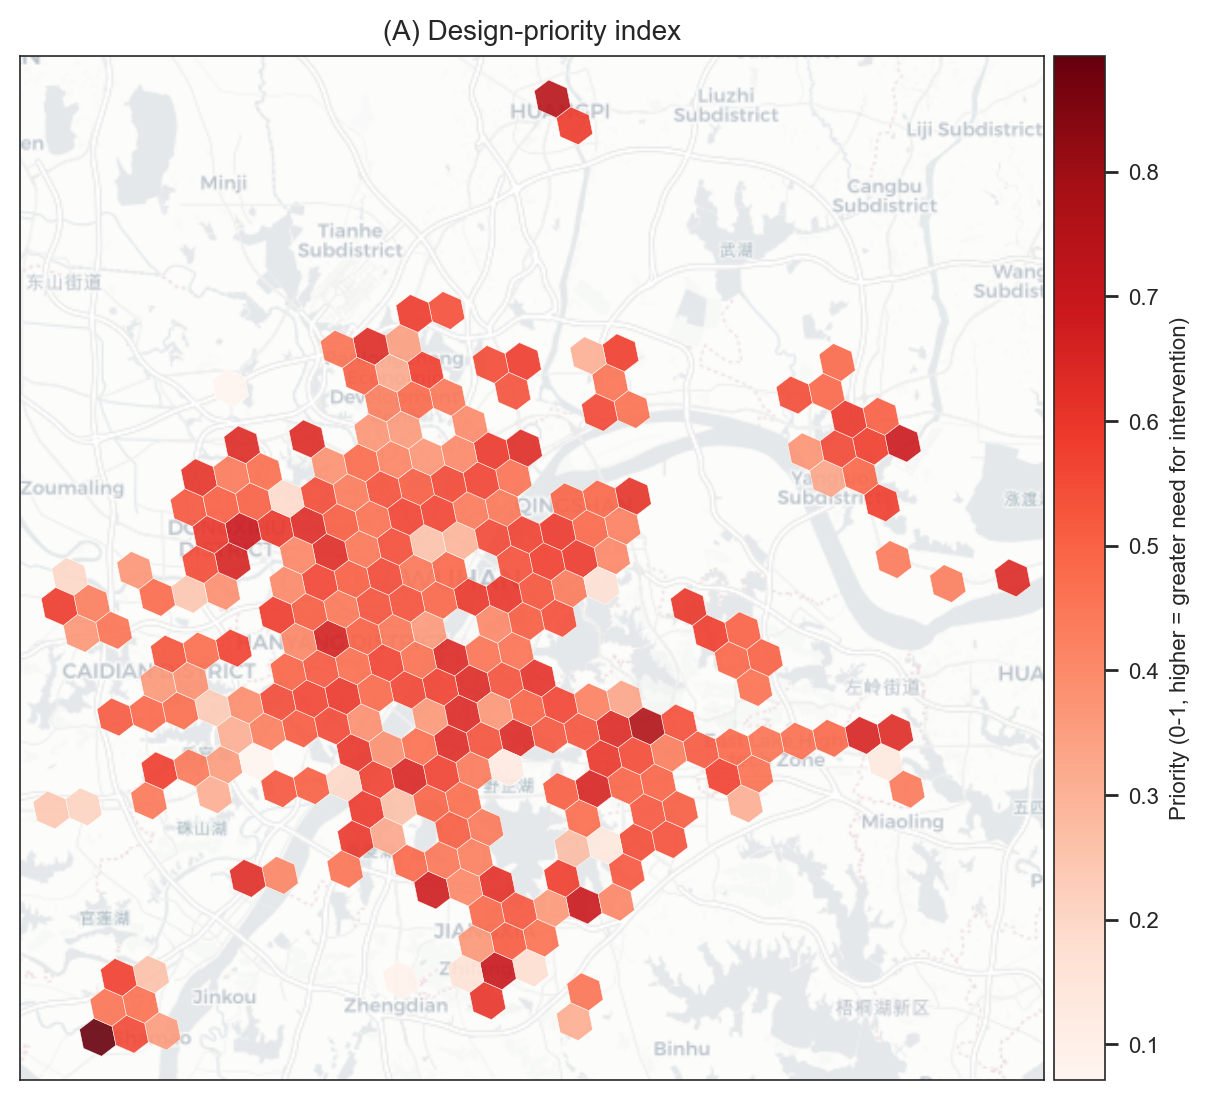

In [5]:
# (A) Design-priority index (decision-support composite, not a deterministic rule)
hex_all["priority"] = (minmax(hex_all["Oppressive"])
                       + minmax(hex_all["Monotonous"])
                       + (1 - minmax(hex_all["Prefer"]))) / 3.0
fig, ax = plt.subplots(figsize=(7, 7))
draw_continuous(ax, hex_all, hex_all["priority"], "Reds",
                "(A) Design-priority index",
                "Priority (0-1, higher = greater need for intervention)")
savefig_all(fig, "figures/code_7_design_priority")
plt.show()

## (B) Indicative design strategy
Each hexagon is assigned the single most actionable strategy based on its dominant visible-environment issue and the associated perceptions. Categories are *indicative guidance*, not prescriptive rules.

strategy
Vertical / facade greening             105
Maintain (low priority)                 68
Add vegetation / pocket parks           48
Road buffering / screen planting        25
Preserve sight corridors / openness     20
Name: count, dtype: int64
saved figures/code_7_strategy_recommendation.png


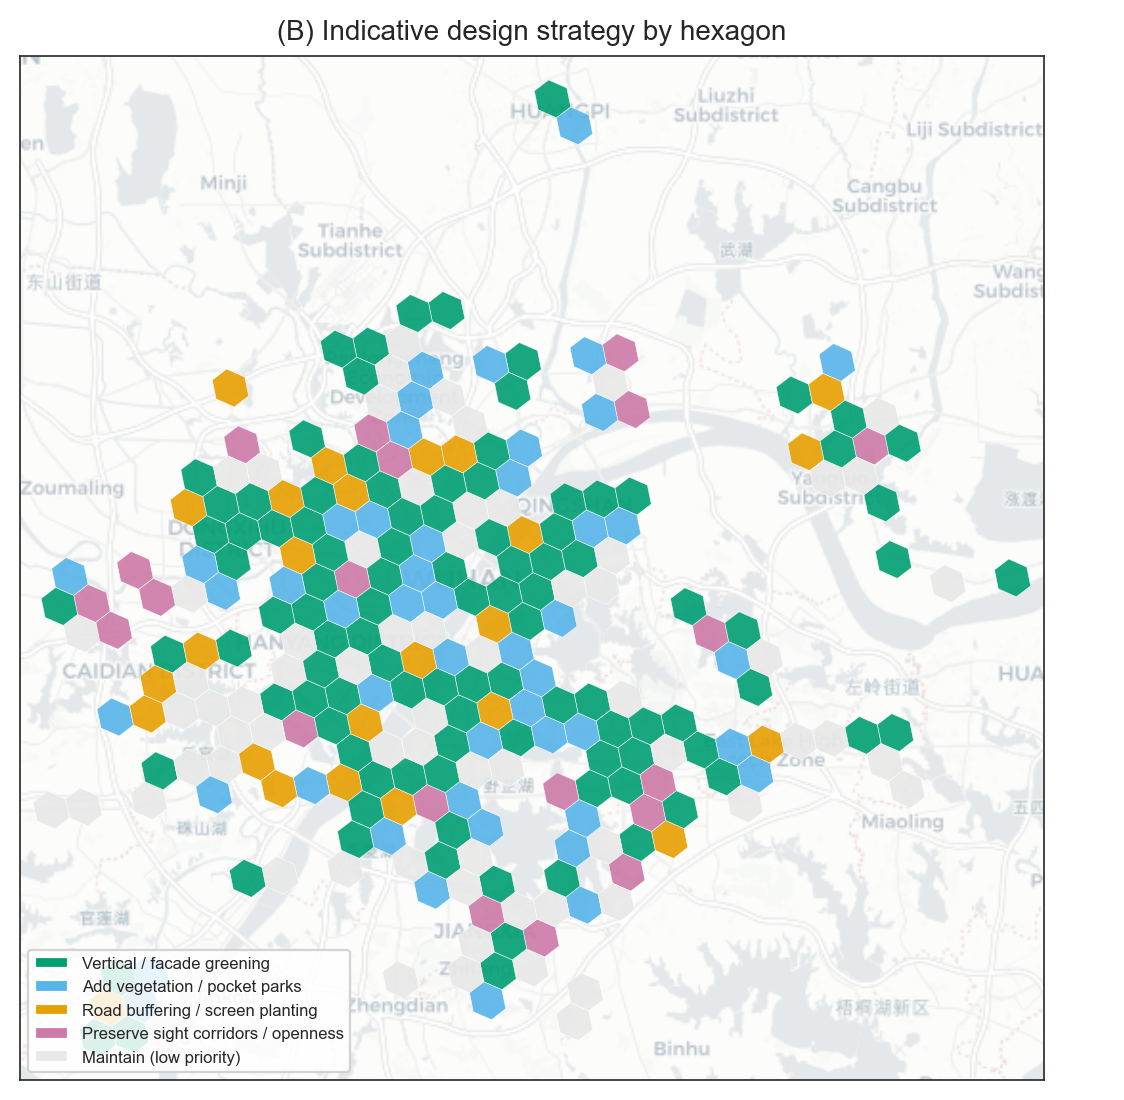

In [6]:
# (B) Indicative design strategy per hexagon
med = {c: hex_all[c].median() for c in WV + PERC}

def recommend(r):
    if r["WV_Highrisebuilding"] > med["WV_Highrisebuilding"] and r["Oppressive"] > med["Oppressive"]:
        return "Vertical / facade greening"
    if r["WV_Tree"] < med["WV_Tree"] and (r["Monotonous"] > med["Monotonous"] or r["Vivid"] < med["Vivid"]):
        return "Add vegetation / pocket parks"
    if r["WV_Road"] > med["WV_Road"] and r["Quiet"] < med["Quiet"]:
        return "Road buffering / screen planting"
    if r["WV_Sky"] < med["WV_Sky"] and r["Extensive"] < med["Extensive"]:
        return "Preserve sight corridors / openness"
    return "Maintain (low priority)"

hex_all["strategy"] = hex_all.apply(recommend, axis=1)
STRAT_COLORS = {
    "Vertical / facade greening":        "#009E73",
    "Add vegetation / pocket parks":     "#56B4E9",
    "Road buffering / screen planting":  "#E69F00",
    "Preserve sight corridors / openness": "#CC79A7",
    "Maintain (low priority)":           "#e8e8e8",
}
print(hex_all["strategy"].value_counts())
fig, ax = plt.subplots(figsize=(7, 7))
draw_categorical(ax, hex_all, hex_all["strategy"], STRAT_COLORS,
                 "(B) Indicative design strategy by hexagon")
savefig_all(fig, "figures/code_7_strategy_recommendation")
plt.show()

## (C) Vertical-greening priority
Hexagons combining high visible high-rise, high *Oppressive*, and little visible greenery are the strongest candidates for green walls, vegetated balconies, and facade greening.

saved figures/code_7_vertical_greening_priority.png


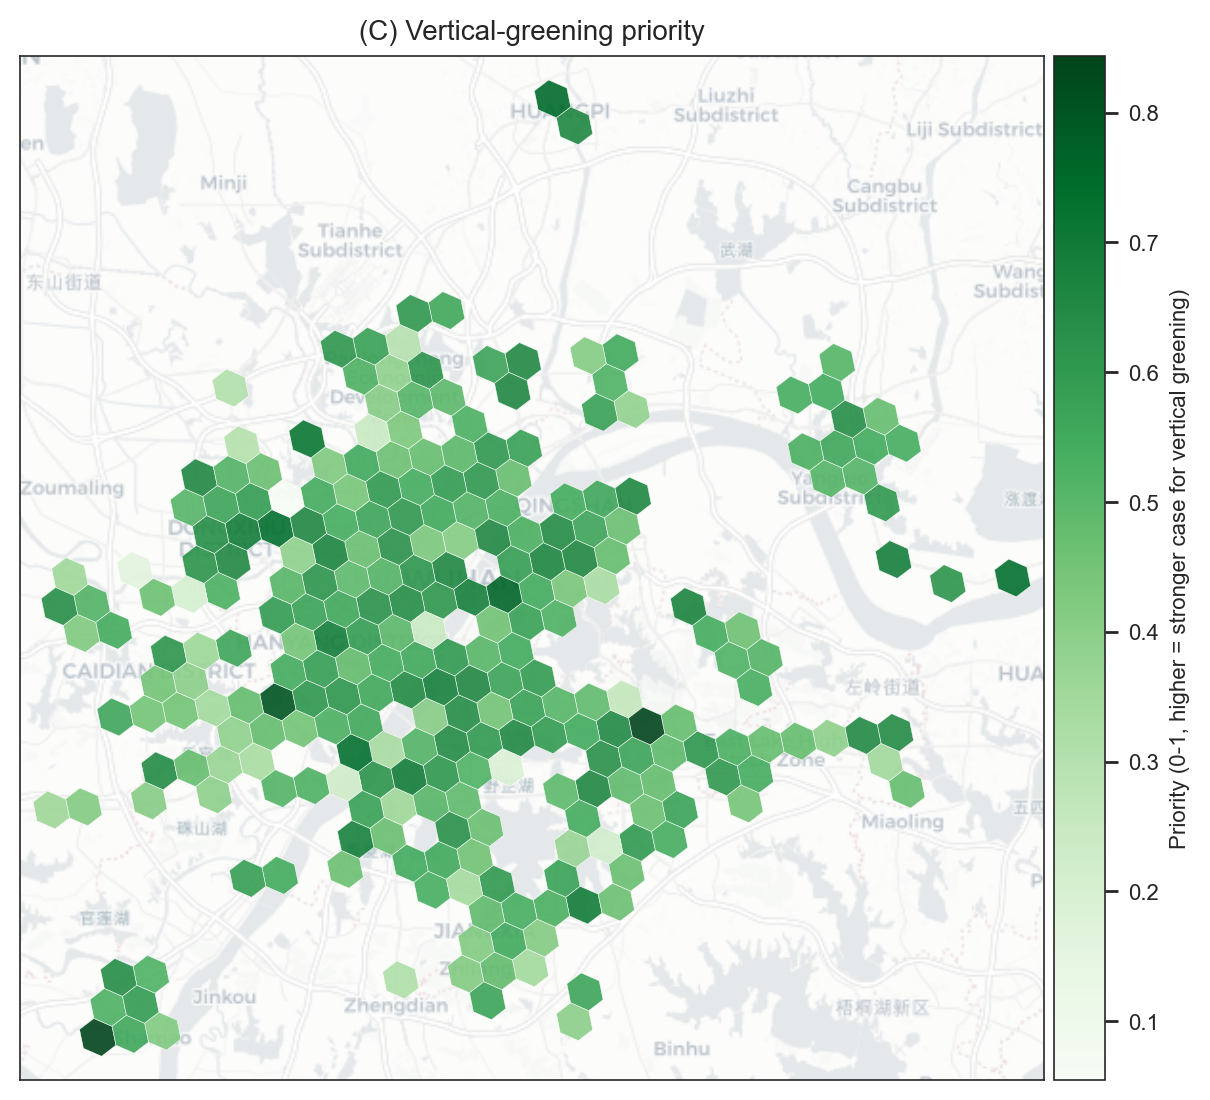

In [7]:
# (C) Vertical-greening priority
hex_all["greening"] = (minmax(hex_all["WV_Highrisebuilding"])
                       + minmax(hex_all["Oppressive"])
                       + (1 - minmax(hex_all["WV_Tree"]))) / 3.0
fig, ax = plt.subplots(figsize=(7, 7))
draw_continuous(ax, hex_all, hex_all["greening"], "Greens",
                "(C) Vertical-greening priority",
                "Priority (0-1, higher = stronger case for vertical greening)")
savefig_all(fig, "figures/code_7_vertical_greening_priority")
plt.show()

## (D) Within-area view-quality inequality
The other maps show hexagon *averages*; this one shows how **uneven** window-view quality is *within* each hexagon (standard deviation of the point-level composite view-quality index across all sampled WVIs). High values flag areas where a good mean hides large disparities between dwellings — an equity dimension for design prioritisation. Hexagons with fewer than 5 sampled WVIs are excluded.

225 hexagons with >= 5 WVIs (of 266)
saved figures/code_7_view_quality_inequality.png


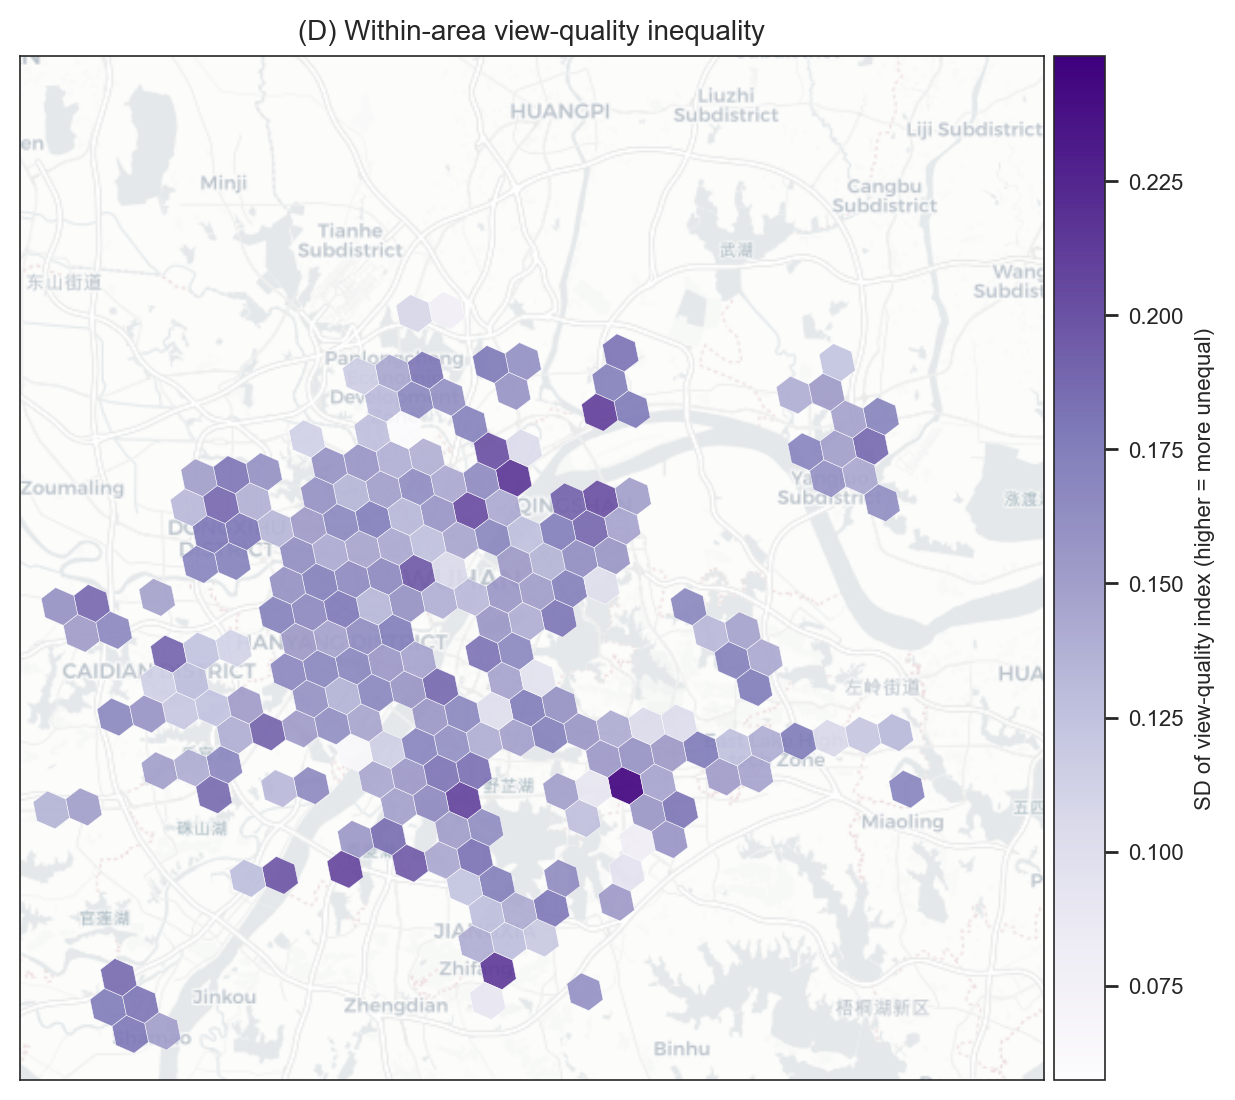

In [8]:
# (D) Within-area view-quality inequality (SD of point-level VQI per hexagon)
# Point-level composite view-quality index (same construction as view_quality(),
# but scaled with point-level min/max so each WVI gets its own score in [0, 1]).
def point_vqi(frame):
    vals = []
    for c in POS:
        s = (frame[c] - df[c].min()) / (df[c].max() - df[c].min() + 1e-12)
        vals.append(s)
    for c in NEG:
        s = (frame[c] - df[c].min()) / (df[c].max() - df[c].min() + 1e-12)
        vals.append(1 - s)
    return np.mean(vals, axis=0)

df["VQI_pt"] = point_vqi(df)
grp = df.groupby("h3_id")["VQI_pt"]
hex_all["inequality"] = hex_all["h3_id"].map(grp.std())
# Require a minimum sample size for a stable dispersion estimate
hex_all.loc[hex_all["n"] < 5, "inequality"] = np.nan
hex_ineq = hex_all[hex_all["inequality"].notna()]
print(f"{len(hex_ineq)} hexagons with >= 5 WVIs (of {len(hex_all)})")

fig, ax = plt.subplots(figsize=(7, 7))
draw_continuous(ax, hex_ineq, hex_ineq["inequality"], "Purples",
                "(D) Within-area view-quality inequality",
                "SD of view-quality index (higher = more unequal)")
savefig_all(fig, "figures/code_7_view_quality_inequality")
plt.show()

## (E) Floor-level guidance
For hexagons sampled at both low and high floors, we compare the composite view-quality index. Positive values (red) mark places where **low-floor** views lag high-floor views and may benefit most from low-level greening or sight-line design.

231 hexagons with both low- and high-floor samples
saved figures/code_7_floor_level_guidance.png


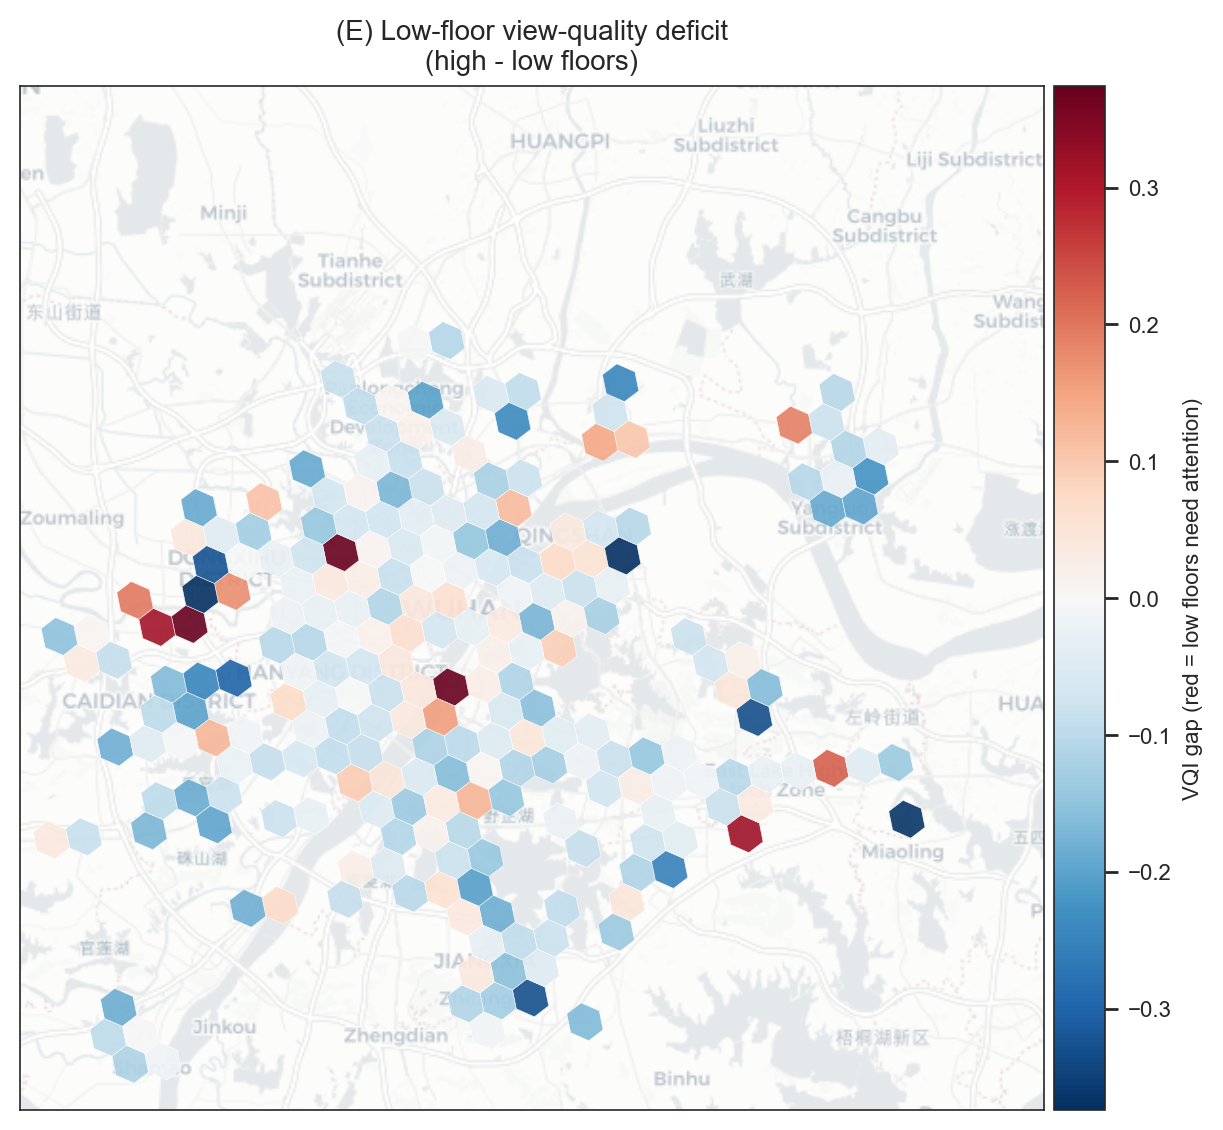

In [9]:
# (E) Low-floor view-quality deficit (high - low floors)
hex_low["VQI"] = view_quality(hex_low)
hex_high["VQI"] = view_quality(hex_high)
mg = hex_low[["h3_id", "VQI"]].merge(hex_high[["h3_id", "VQI"]],
                                     on="h3_id", suffixes=("_low", "_high"))
mg["gap"] = mg["VQI_high"] - mg["VQI_low"]   # positive => low floors worse
print(f"{len(mg)} hexagons with both low- and high-floor samples")

vmax = float(np.nanpercentile(np.abs(mg["gap"]), 98))
fig, ax = plt.subplots(figsize=(7, 7))
draw_continuous(ax, mg, mg["gap"], "RdBu_r",
                "(E) Low-floor view-quality deficit\n(high - low floors)",
                "VQI gap (red = low floors need attention)", vmin=-vmax, vmax=vmax)
savefig_all(fig, "figures/code_7_floor_level_guidance")
plt.show()

## (F) Composite window-view quality index
A single citywide index combining the six perception dimensions (positive dimensions plus the inverse of the negative ones). Cold (low) areas are design-priority zones; warm areas are reference exemplars of good window-view quality.

saved figures/code_7_view_quality_index.png


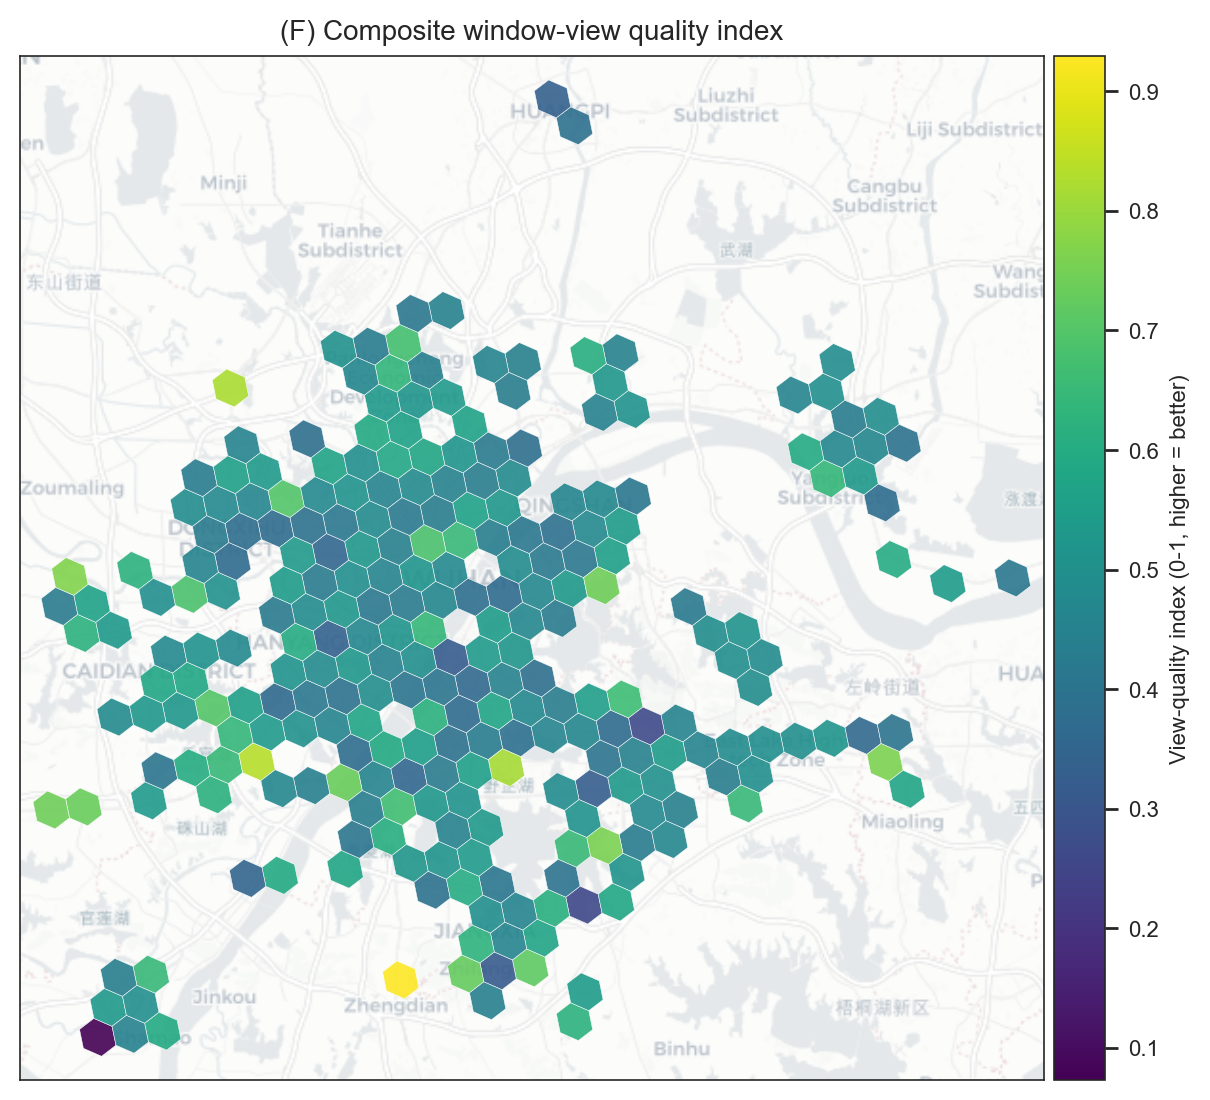

In [10]:
# (F) Composite window-view quality index (citywide)
hex_all["VQI"] = view_quality(hex_all)
fig, ax = plt.subplots(figsize=(7, 7))
draw_continuous(ax, hex_all, hex_all["VQI"], "viridis",
                "(F) Composite window-view quality index",
                "View-quality index (0-1, higher = better)")
savefig_all(fig, "figures/code_7_view_quality_index")
plt.show()

## Value distributions of the six maps

Histograms of the hexagon-level values underlying each map panel (A, C–F), plus the category counts for the indicative design strategy (B). Useful for choosing sensible colour ranges (`RANGES`) in the combined overview below.

saved figures/code_7_map_value_distributions.png


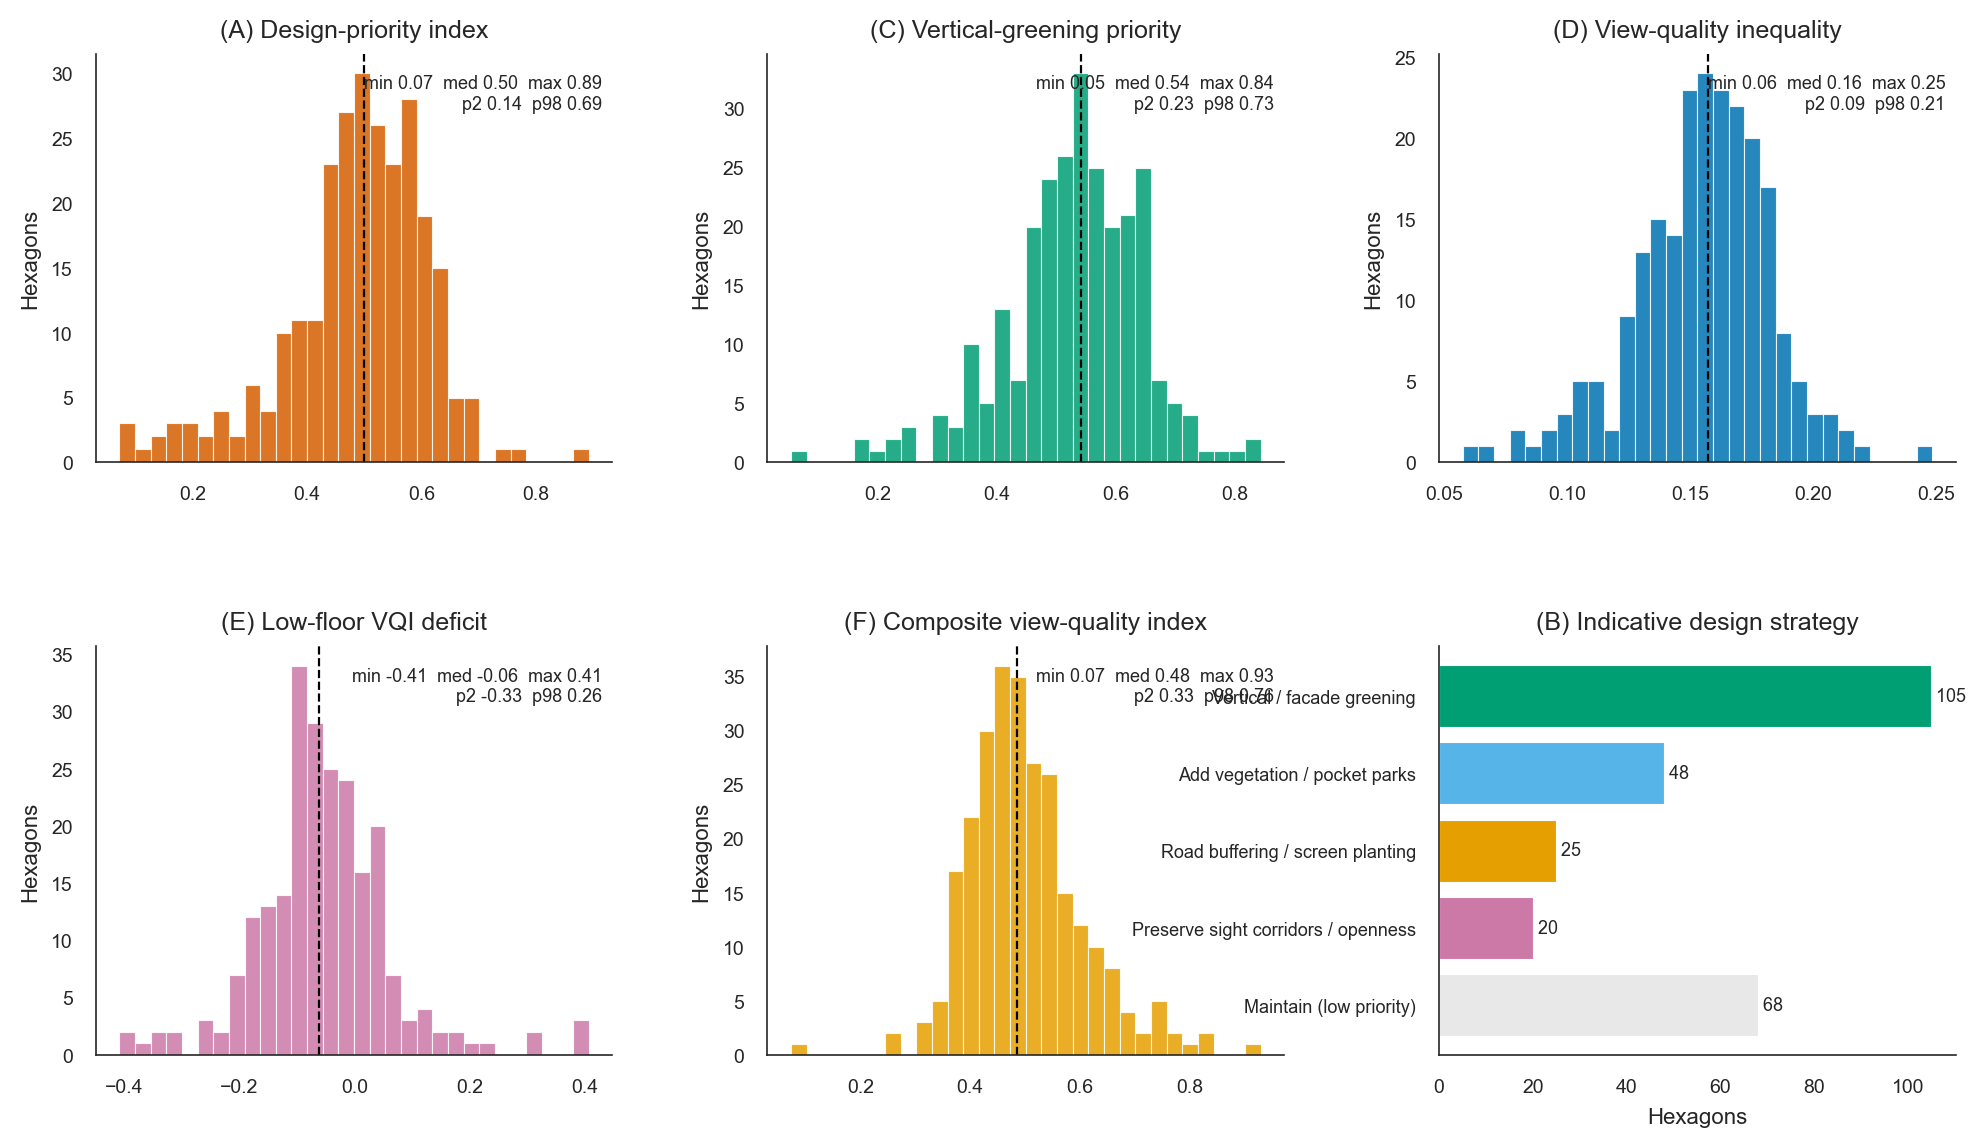

In [11]:
# Distributions of the values mapped in panels (A)-(F)
DIST = [
    ("(A) Design-priority index",        hex_all["priority"], "#D55E00"),
    ("(C) Vertical-greening priority",   hex_all["greening"], "#009E73"),
    ("(D) View-quality inequality",      hex_ineq["inequality"], "#0072B2"),
    ("(E) Low-floor VQI deficit",        mg["gap"],           "#CC79A7"),
    ("(F) Composite view-quality index", hex_all["VQI"],      "#E69F00"),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
fig.subplots_adjust(hspace=0.45, wspace=0.30)

for ax, (label, vals, color) in zip(axes.flat, DIST):
    vals = np.asarray(vals, float)
    ax.hist(vals, bins=30, color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    med = np.nanmedian(vals)
    ax.axvline(med, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel("Hexagons", fontsize=8)
    stats = (f"min {np.nanmin(vals):.2f}  med {med:.2f}  max {np.nanmax(vals):.2f}\n"
             f"p2 {np.nanpercentile(vals, 2):.2f}  p98 {np.nanpercentile(vals, 98):.2f}")
    ax.text(0.98, 0.95, stats, transform=ax.transAxes, ha="right", va="top", fontsize=6.5)

# (B) Indicative design strategy: category counts
axb = axes.flat[5]
counts = hex_all["strategy"].value_counts().reindex(list(STRAT_COLORS)).fillna(0)
axb.barh(range(len(counts)), counts.values,
         color=[STRAT_COLORS[k] for k in counts.index], edgecolor="white", linewidth=0.4)
axb.set_yticks(range(len(counts)))
axb.set_yticklabels(counts.index, fontsize=6.5)
axb.invert_yaxis()
axb.set_title("(B) Indicative design strategy", fontsize=9)
axb.set_xlabel("Hexagons", fontsize=8)
for i, v in enumerate(counts.values):
    axb.text(v, i, f" {int(v)}", va="center", fontsize=6.5)

sns.despine(fig=fig)
savefig_all(fig, "figures/code_7_map_value_distributions")
plt.show()

## Combined overview (2 x 3)

All six design-support maps assembled into a single 2 x 3 panel for an at-a-glance comparison.

saved figures/code_7_design_overview.png


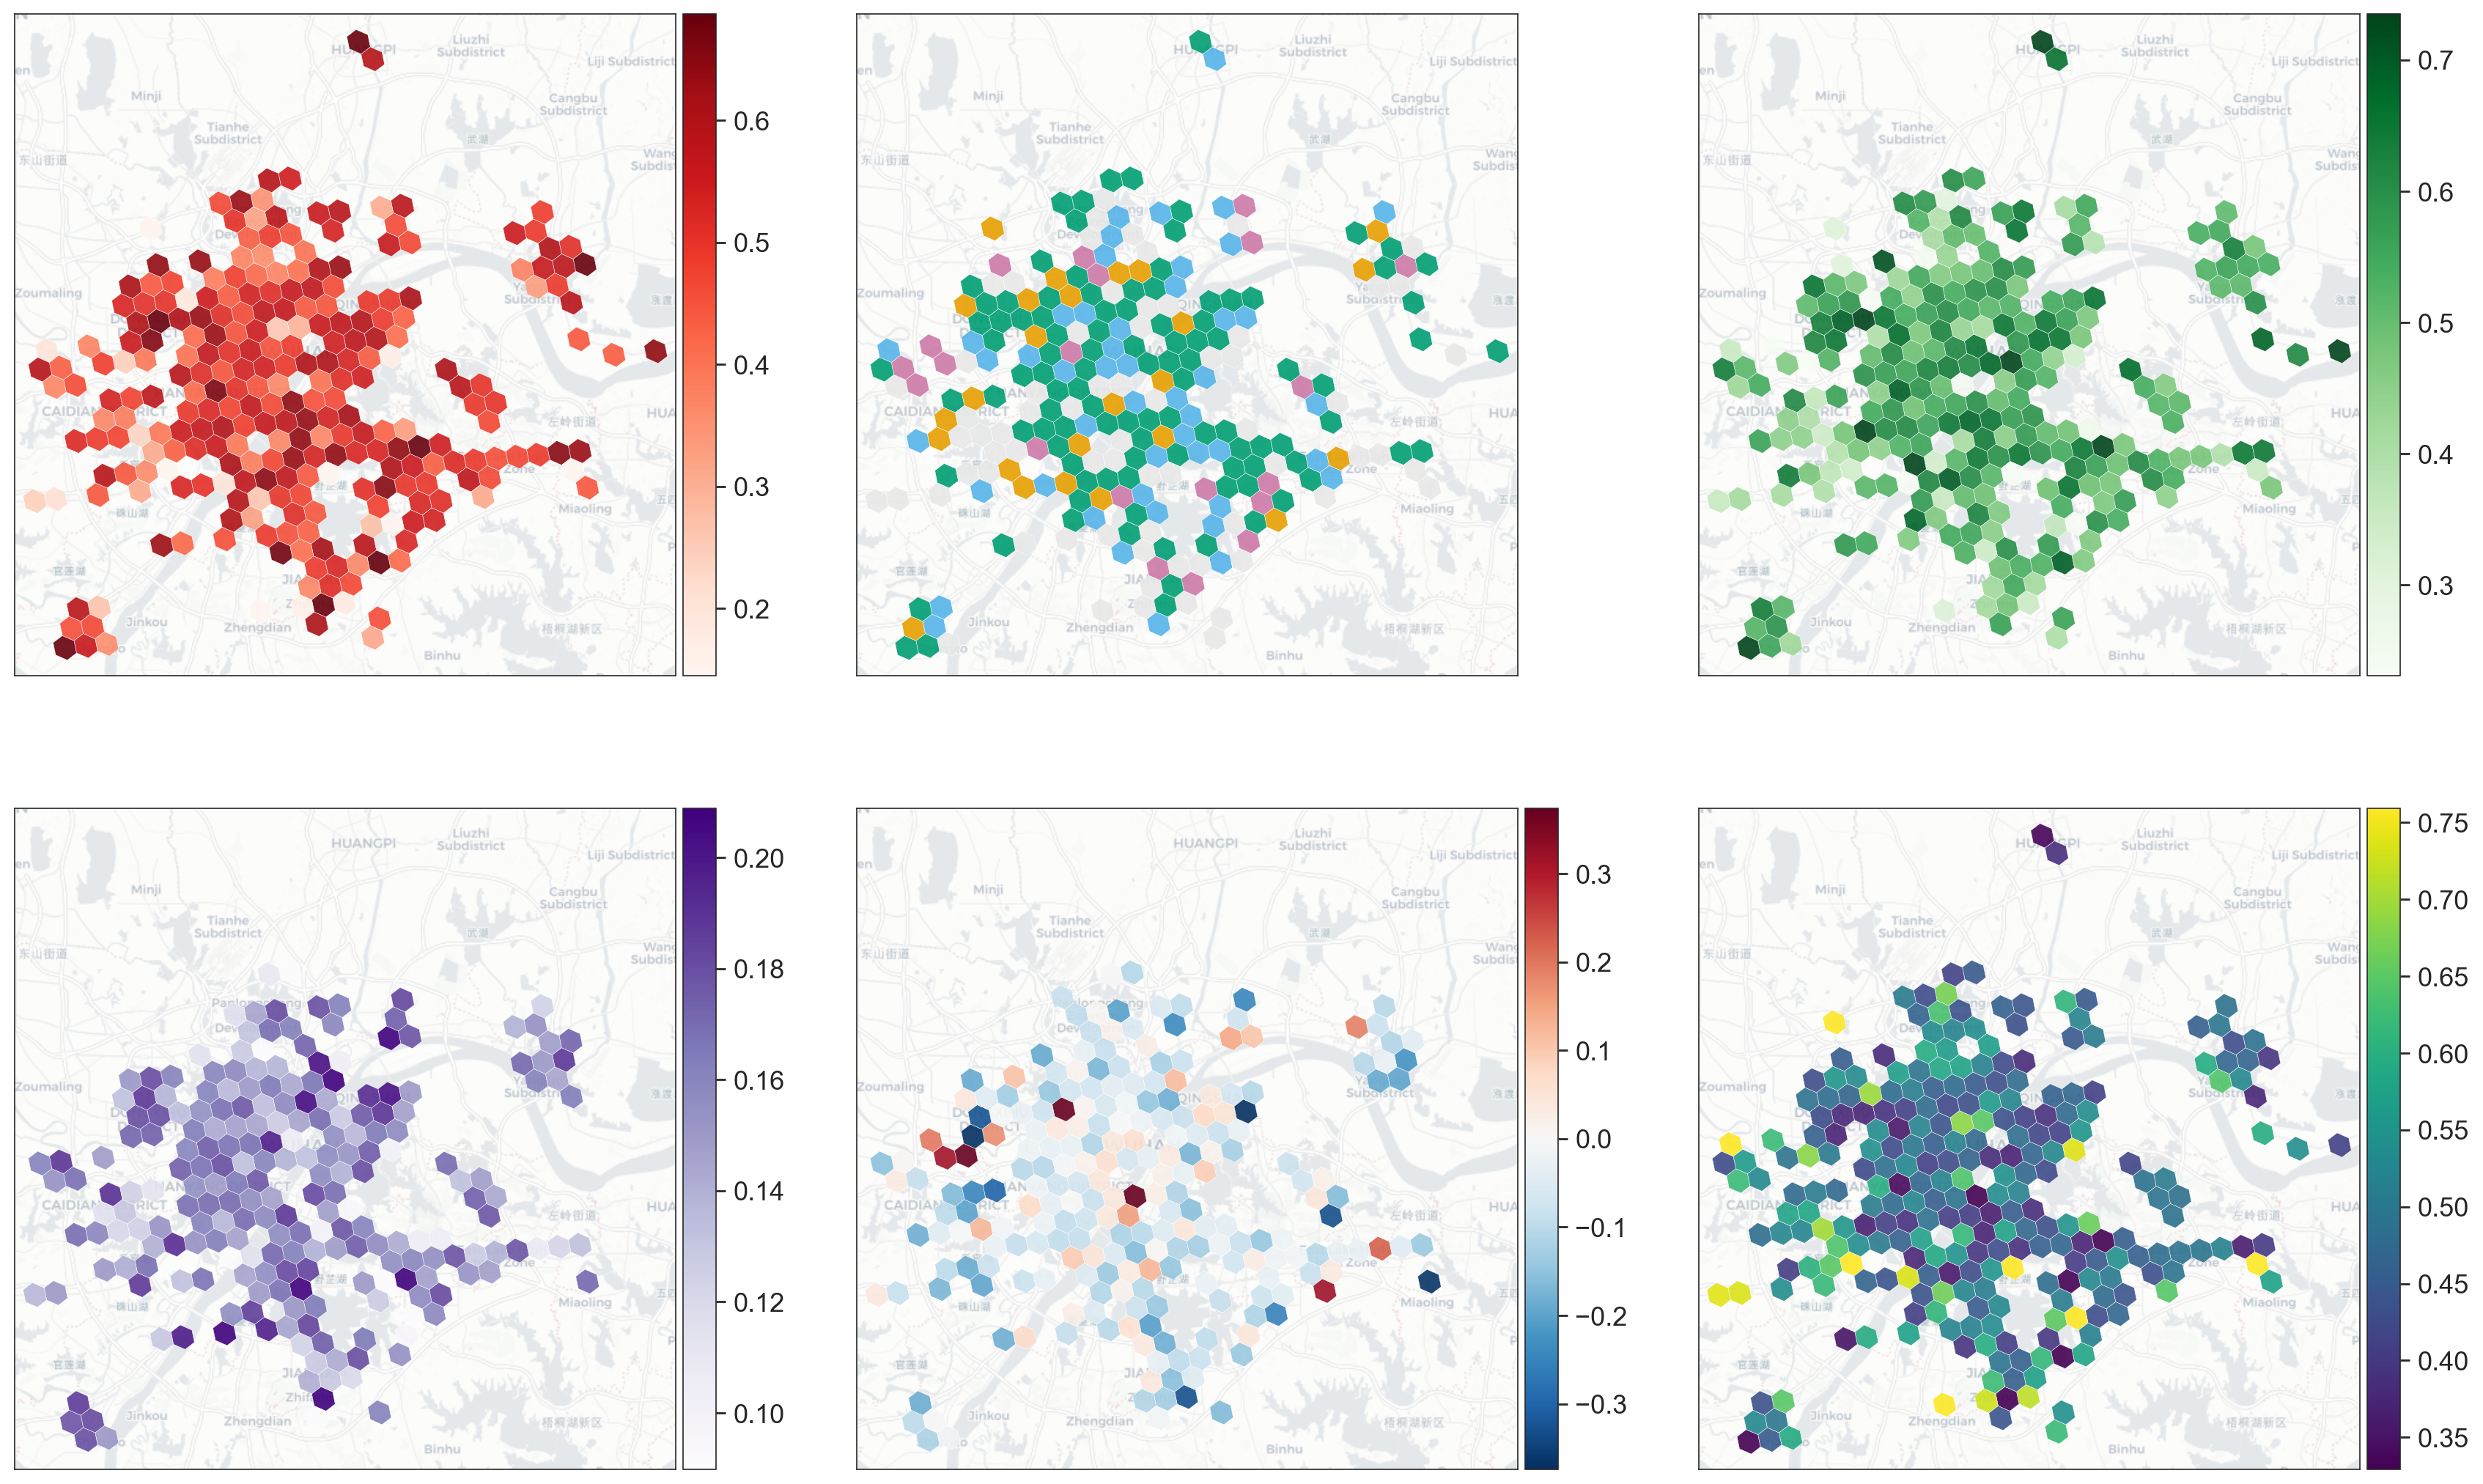

In [12]:
# Combined 2 x 3 overview of all six design-support maps (no titles, larger legend)
CBFS = 13  # colorbar font size for the combined overview

# ---- Per-panel colour value ranges (vmin, vmax). Set None to auto-scale. ----
# Edit these to fix what value each colour maps to in every panel.
# Defaults: p2-p98 of each variable (E kept symmetric around 0).
_p = lambda s: tuple(np.nanpercentile(np.asarray(s, float), [2, 98]))
_vmax_e = float(np.nanpercentile(np.abs(mg["gap"]), 98))   # symmetric default for (E)
RANGES = {
    "A": _p(hex_all["priority"]),     # Design-priority index
    "C": _p(hex_all["greening"]),     # Vertical-greening priority
    "D": _p(hex_ineq["inequality"]),  # Within-area view-quality inequality
    "E": (-_vmax_e, _vmax_e),         # Low-floor view-quality deficit
    "F": _p(hex_all["VQI"]),          # Composite view-quality index
}

fig, axes = plt.subplots(2, 3, figsize=(21, 14))
fig.subplots_adjust(hspace=0.01, wspace=0.20)

# (A) Design-priority index
draw_continuous(axes[0, 0], hex_all, hex_all["priority"], "Reds",
                "", "", vmin=RANGES["A"][0], vmax=RANGES["A"][1], cbar_fontsize=CBFS)
# (B) Indicative design strategy
draw_categorical(axes[0, 1], hex_all, hex_all["strategy"], STRAT_COLORS,
                 "", show_legend=False)
# (C) Vertical-greening priority
draw_continuous(axes[0, 2], hex_all, hex_all["greening"], "Greens",
                "", "", vmin=RANGES["C"][0], vmax=RANGES["C"][1], cbar_fontsize=CBFS)
# (D) Within-area view-quality inequality
draw_continuous(axes[1, 0], hex_ineq, hex_ineq["inequality"], "Purples",
                "", "", vmin=RANGES["D"][0], vmax=RANGES["D"][1], cbar_fontsize=CBFS)
# (E) Low-floor view-quality deficit
draw_continuous(axes[1, 1], mg, mg["gap"], "RdBu_r",
                "", "", vmin=RANGES["E"][0], vmax=RANGES["E"][1], cbar_fontsize=CBFS)
# (F) Composite view-quality index
draw_continuous(axes[1, 2], hex_all, hex_all["VQI"], "viridis",
                "", "", vmin=RANGES["F"][0], vmax=RANGES["F"][1], cbar_fontsize=CBFS)

savefig_all(fig, "figures/code_7_design_overview")
plt.show()